In [1]:
####load packages
import scdrs
import scanpy as sc
sc.set_figure_params(dpi=300)
from anndata import AnnData
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

In [4]:
# load adata
adata = sc.read_h5ad("/public/work/Personal/renxiaozhen/pipline/scDRS/data/single_cell_data/zeisel_2015/expr.h5ad")

# subset gene sets
df_gs = pd.read_csv("/public/work/Personal/renxiaozhen/pipline/scDRS/data/single_cell_data/zeisel_2015/geneset.gs", sep="\t", index_col=0)

df_gs = df_gs.loc[
    [
        "PASS_Schizophrenia_Pardinas2018",
        "spatial_dorsal",
        "UKB_460K.body_HEIGHTz",
    ],
    :,
].rename(
    {
        "PASS_Schizophrenia_Pardinas2018": "SCZ",
        "spatial_dorsal": "Dorsal",
        "UKB_460K.body_HEIGHTz": "Height",
    }
)
display(df_gs)

df_gs.to_csv("/public/work/Personal/renxiaozhen/pipline/scDRS/data/processed_geneset.gs", sep="\t")

,GENESET
TRAIT,
SCZ,"Dpyd:7.6519,Cacna1i:7.4766,Rbfox1:7.3247,Ppp1r..."
Dorsal,"Ckb,Fndc5,Lin7b,Gstm7,Tle1,Cabp7,Etv5,Actn1,Sa..."
Height,"Wwox:10,Bnc2:10,Gmds:10,Lpp:9.9916,Prkg1:9.836..."


In [8]:
adata.var

,BackSPIN,n_cells
gene,,
Tspan12,1,472
Tshz1,1,573
Fnbp1l,1,1167
Adamts15,1,77
Cldn12,1,669
...,...,...
Vamp7,0,1714
Tmlhe,0,84
Zf12,0,103


In [4]:
##scDRS analysis of disease enrichment for individual cells
%%capture

!scdrs compute-score \
    --h5ad-file /public/work/Personal/renxiaozhen/pipline/scDRS/data/single_cell_data/zeisel_2015/expr.h5ad \
    --h5ad-species mouse \
    --gs-file /public/work/Personal/renxiaozhen/pipline/scDRS/data/processed_geneset.gs \
    --gs-species mouse \
    --cov-file /public/work/Personal/renxiaozhen/pipline/scDRS/data/single_cell_data/zeisel_2015/cov.tsv \
    --flag-filter-data True \
    --flag-raw-count True \
    --flag-return-ctrl-raw-score False \
    --flag-return-ctrl-norm-score True \
    --out-folder /public/work/Personal/renxiaozhen/pipline/scDRS/data/

In [14]:
display(dict_score)

{'SCZ':                 raw_score  norm_score   mc_pval      pval  nlog10_pval  \
 cell_id                                                                  
 1772071015_C02   0.207257   -0.511361  0.679321  0.691314     0.160325   
 1772071017_G12   0.230835    1.199612  0.124875  0.116294     0.934443   
 1772071017_A05   0.214898    1.231413  0.117882  0.110362     0.957180   
 1772071014_B06   0.190815   -0.730905  0.754246  0.765372     0.116127   
 1772067065_H06   0.229647    0.965739  0.157842  0.166621     0.778270   
 ...                   ...         ...       ...       ...          ...   
 1772067059_B04   0.222245   -0.432847  0.649351  0.662638     0.178724   
 1772066097_D04   0.203599   -0.555075  0.716284  0.706764     0.150725   
 1772063068_D01   0.279663    3.775744  0.001998  0.000177     3.751933   
 1772066098_A12   0.195696   -0.585736  0.714286  0.717375     0.144254   
 1772058148_F03   0.221701   -0.016544  0.498501  0.500288     0.300780   
 
                

In [15]:
display(adata.obs)

,tissue,group #,total mRNA mol,well,sex,age,diameter,level1class,level2class,n_genes,leiden,SCZ,Dorsal,Height
cell_id,,,,,,,,,,,,,,
1772071015_C02,sscortex,1,21580.0,11,1,21,0,interneurons,Int10,4848,8,-0.511361,1.213004,0.795254
1772071017_G12,sscortex,1,21748.0,95,-1,20,9.56,interneurons,Int10,4685,8,1.199612,-1.275429,1.447106
1772071017_A05,sscortex,1,31642.0,33,-1,20,11.1,interneurons,Int6,6028,8,1.231413,-0.933427,0.058795
1772071014_B06,sscortex,1,32916.0,42,1,21,11.7,interneurons,Int10,5824,8,-0.730905,-0.474961,1.042666
1772067065_H06,sscortex,1,21531.0,48,1,25,11,interneurons,Int9,4701,8,0.965739,1.034220,1.531764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1772067059_B04,ca1hippocampus,9,4585.0,26,-1,23,9.85,endothelial-mural,Peric,2221,2,-0.432847,-0.047255,1.070429
1772066097_D04,ca1hippocampus,9,2559.0,28,-1,26,11,endothelial-mural,Vsmc,1428,2,-0.555075,0.331502,1.768402
1772063068_D01,sscortex,9,4015.0,4,1,26,8.63,endothelial-mural,Vsmc,1977,14,3.775744,2.613803,0.037213


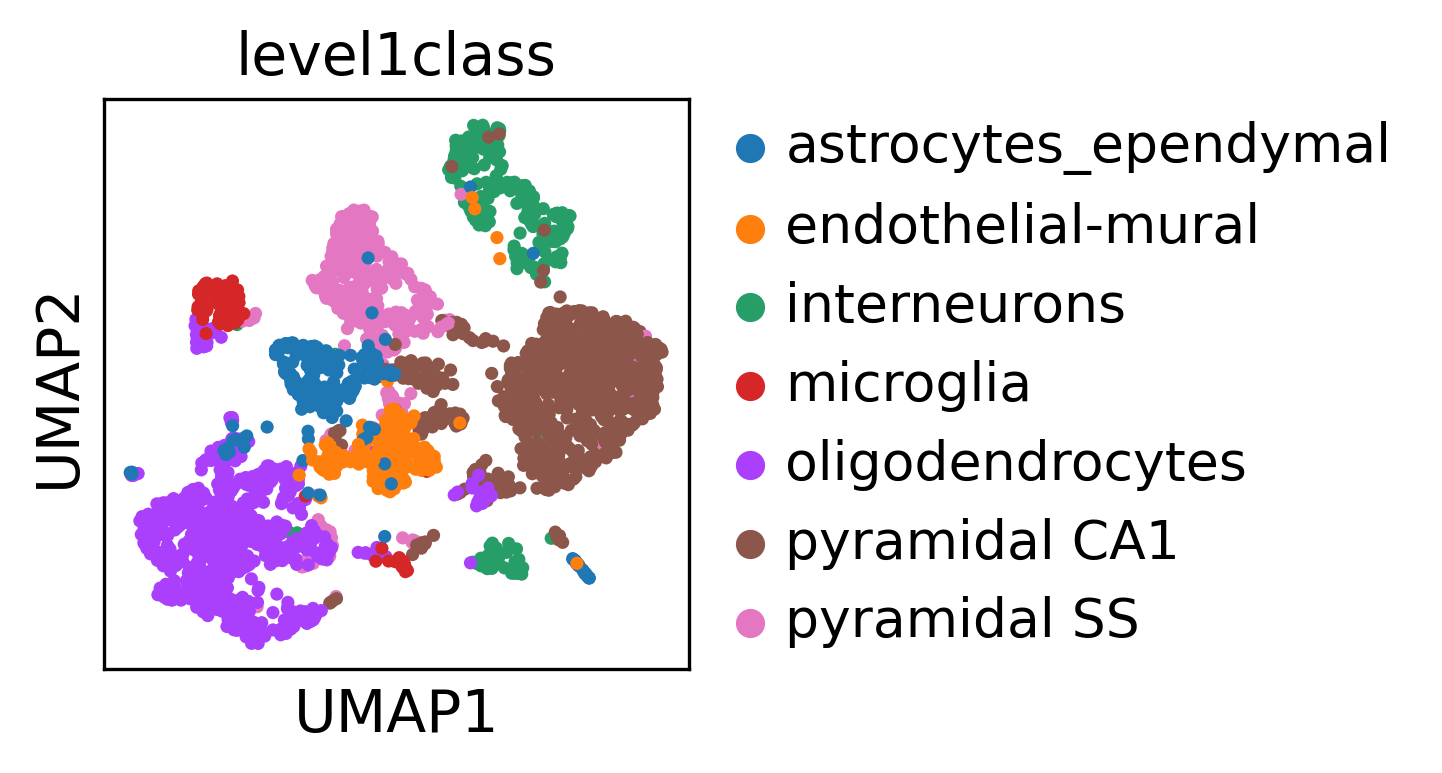

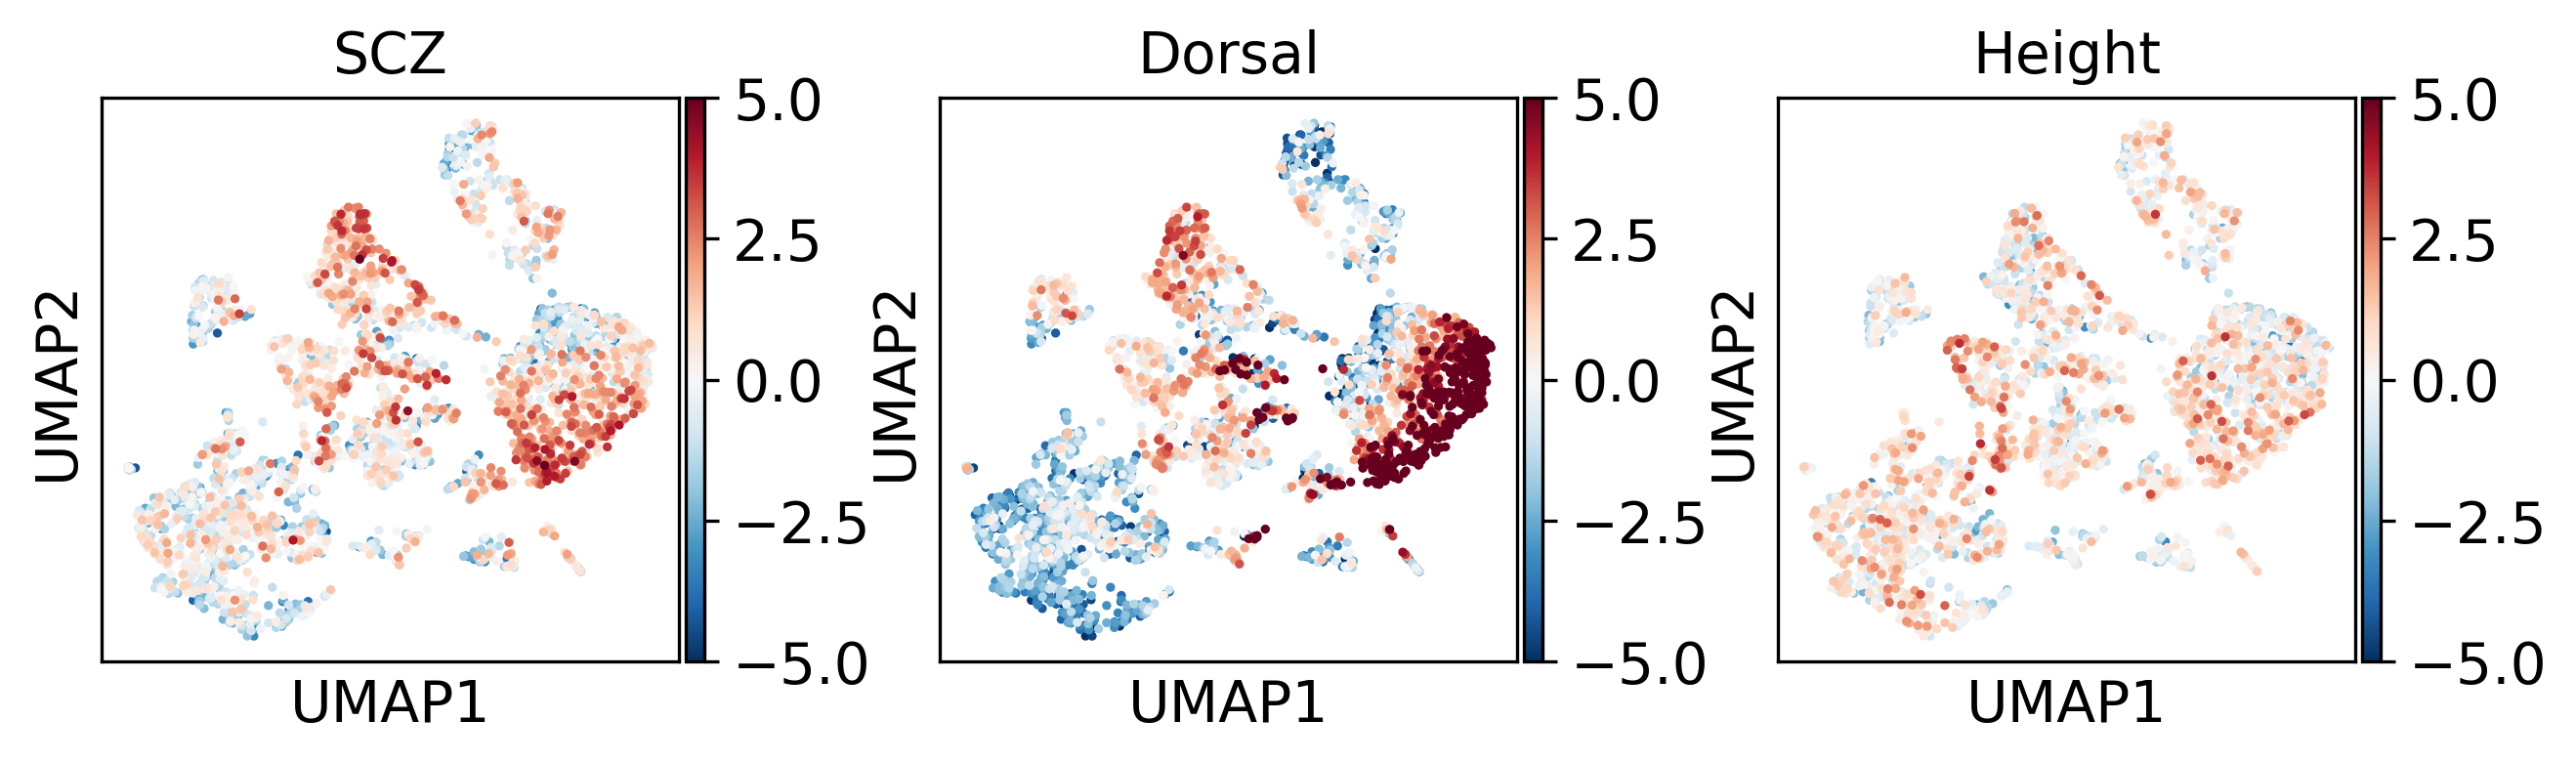

In [11]:
dict_score = {
    trait: pd.read_csv(f"/public/work/Personal/renxiaozhen/pipline/scDRS/data/{trait}.full_score.gz", sep="\t", index_col=0)
    for trait in df_gs.index
}

for trait in dict_score:
    adata.obs[trait] = dict_score[trait]["norm_score"]

sc.settings.figdir = "/public/work/Personal/renxiaozhen/pipline/scDRS"
sc.set_figure_params(figsize=[2.5, 2.5], dpi=150)
sc.pl.umap(
    adata,
    color="level1class",
    ncols=1,
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    show = False
)
plt.savefig("/public/work/Personal/renxiaozhen/pipline/scDRS/aaa.png")

sc.pl.umap(
    adata,
    color=dict_score.keys(),
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
    save = "ddd.png"
)
# plt.savefig("/public/work/Personal/renxiaozhen/pipline/scDRS/ddd.png")

In [21]:
%%capture
#scDRS test of group level statistics

for trait in ["SCZ", "Height"]:
    !scdrs perform-downstream \
        --h5ad-file /public/work/Personal/renxiaozhen/pipline/scDRS/data/single_cell_data/zeisel_2015/expr.h5ad \
        --score-file /public/work/Personal/renxiaozhen/pipline/scDRS/data/{trait}.full_score.gz \
        --out-folder /public/work/Personal/renxiaozhen/pipline/scDRS/data/ \
        --group-analysis level1class \
        --flag-filter-data True \
        --flag-raw-count True

In [22]:
# scDRS group-level statistics for SCZ
!cat /public/work/Personal/renxiaozhen/pipline/scDRS/data/SCZ.scdrs_group.level1class | column -t -s $'\t'

group                 n_cell  n_ctrl  assoc_mcp    assoc_mcz    hetero_mcp   hetero_mcz  n_fdr_0.05  n_fdr_0.1  n_fdr_0.2
astrocytes_ependymal  224.0   1000.0  0.007992008  2.755896     0.002997003  3.0352552   6.0         12.0       23.0
endothelial-mural     235.0   1000.0  0.14085914   1.0441228    0.051948052  1.8254294   6.0         9.0        11.0
interneurons          290.0   1000.0  0.17982018   0.8516827    0.005994006  3.029439    0.0         3.0        13.0
microglia             98.0    1000.0  0.43956044   0.09781444   0.17782217   0.9301765   0.0         2.0        3.0
oligodendrocytes      820.0   1000.0  0.7672328    -0.73165476  0.000999001  5.0373654   1.0         4.0        11.0
pyramidal CA1         939.0   1000.0  0.000999001  7.7077475    0.000999001  9.697397    50.0        105.0      189.0
pyramidal SS          399.0   1000.0  0.000999001  5.78891      0.000999001  6.059032    26.0        43.0       70.0


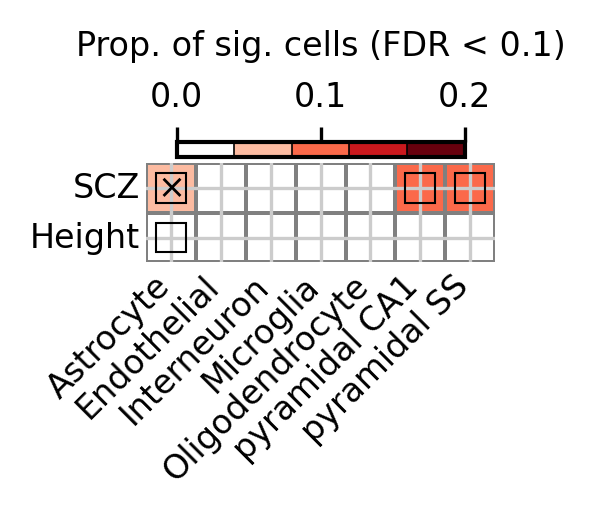

In [3]:
dict_df_stats = {
    trait: pd.read_csv(f"/public/work/Personal/renxiaozhen/pipline/scDRS/data/{trait}.scdrs_group.level1class", sep="\t", index_col=0)
    for trait in ["SCZ", "Height"]
}
dict_celltype_display_name = {
    "pyramidal_CA1": "Pyramidal CA1",
    "oligodendrocytes": "Oligodendrocyte",
    "pyramidal_SS": "Pyramidal SS",
    "interneurons": "Interneuron",
    "endothelial-mural": "Endothelial",
    "astrocytes_ependymal": "Astrocyte",
    "microglia": "Microglia",
}

fig, ax = scdrs.util.plot_group_stats(
    dict_df_stats={
        trait: df_stats.rename(index=dict_celltype_display_name)
        for trait, df_stats in dict_df_stats.items()
    },
    plot_kws={
        "vmax": 0.2,
        "cb_fraction":0.12
    }
)
plt.savefig("/public/work/Personal/renxiaozhen/pipline/scDRS/cc.png", bbox_inches = 'tight')

In [12]:
# extract CA1 pyramidal neurons and perform a re-clustering
adata_ca1 = adata[adata.obs["level2class"].isin(["CA1Pyr1", "CA1Pyr2"])].copy()
sc.pp.filter_cells(adata_ca1, min_genes=0)
sc.pp.filter_genes(adata_ca1, min_cells=1)
sc.pp.normalize_total(adata_ca1, target_sum=1e4)
sc.pp.log1p(adata_ca1)

sc.pp.highly_variable_genes(adata_ca1, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_ca1 = adata_ca1[:, adata_ca1.var.highly_variable]
sc.pp.scale(adata_ca1, max_value=10)
sc.tl.pca(adata_ca1, svd_solver="arpack")

sc.pp.neighbors(adata_ca1, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_ca1, n_components=2)

# assign scDRS score
for trait in dict_score:
    adata_ca1.obs[trait] = dict_score[trait]["norm_score"]

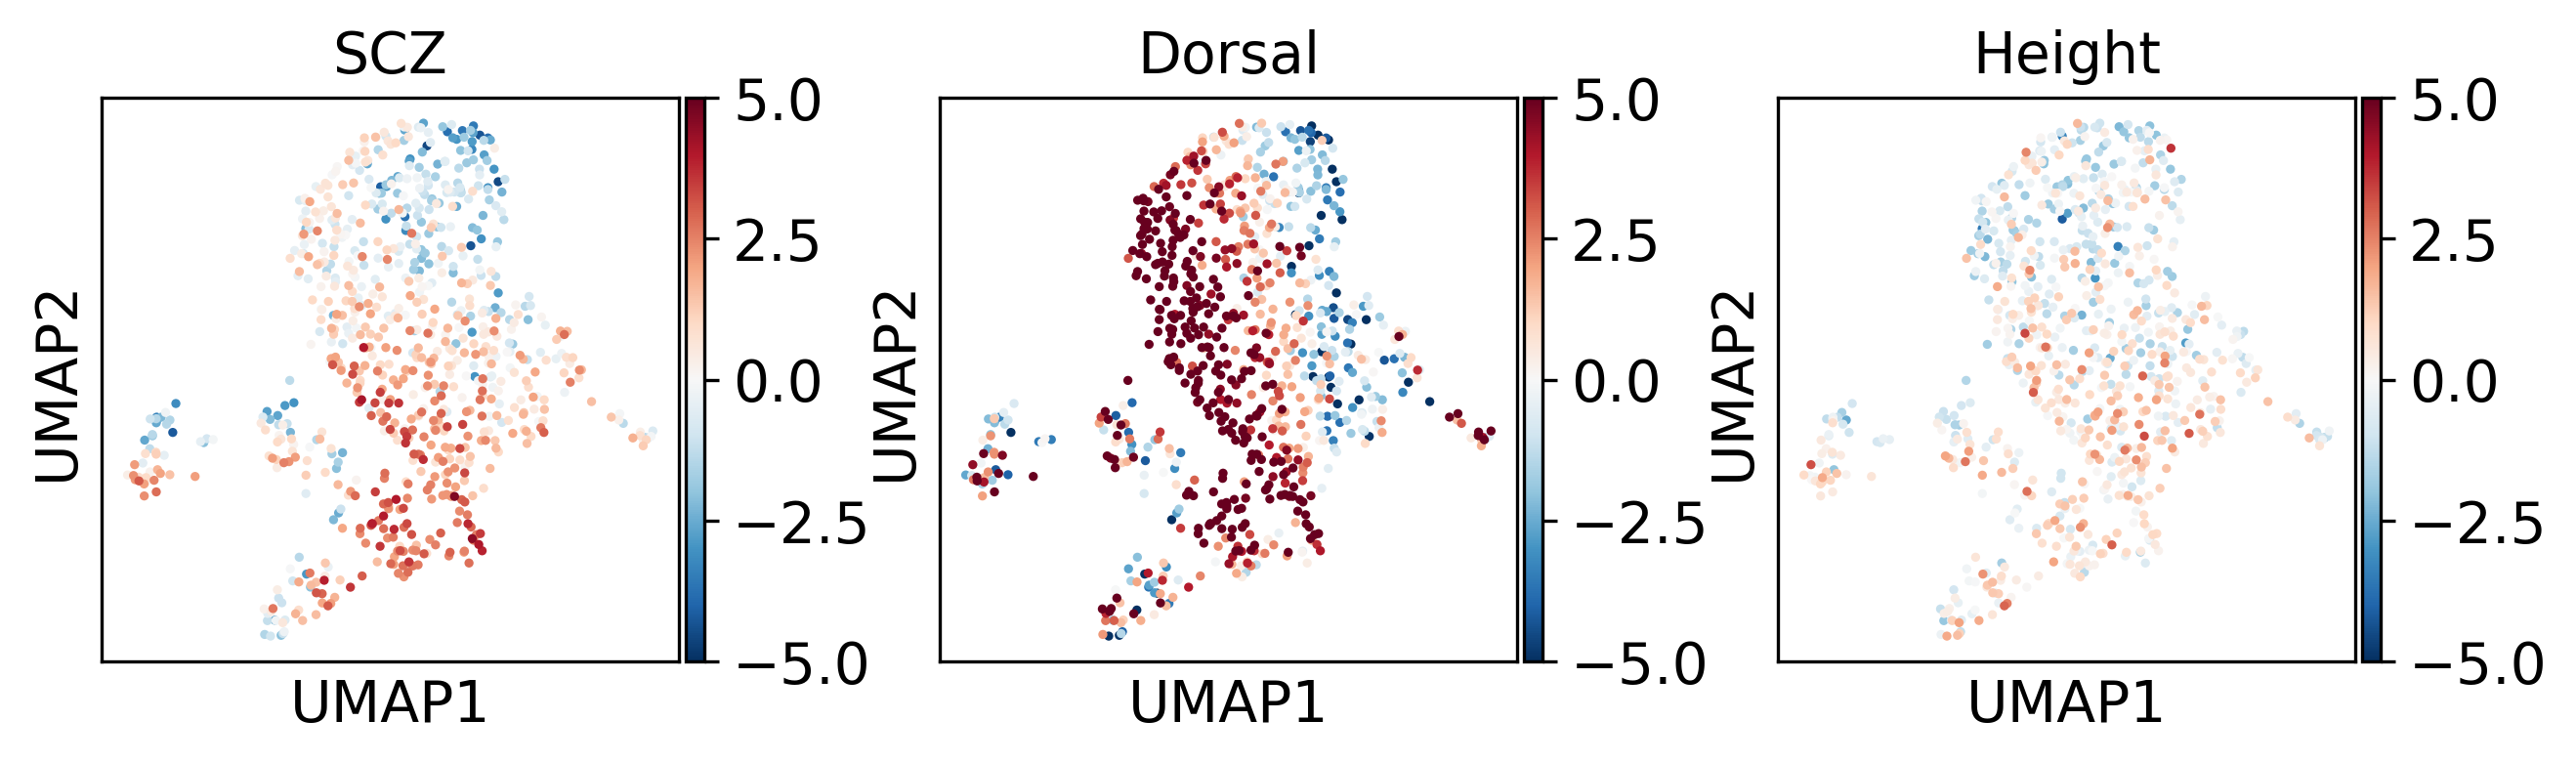

In [19]:
sc.pl.umap(
    adata_ca1,
    color=dict_score.keys(),
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
)

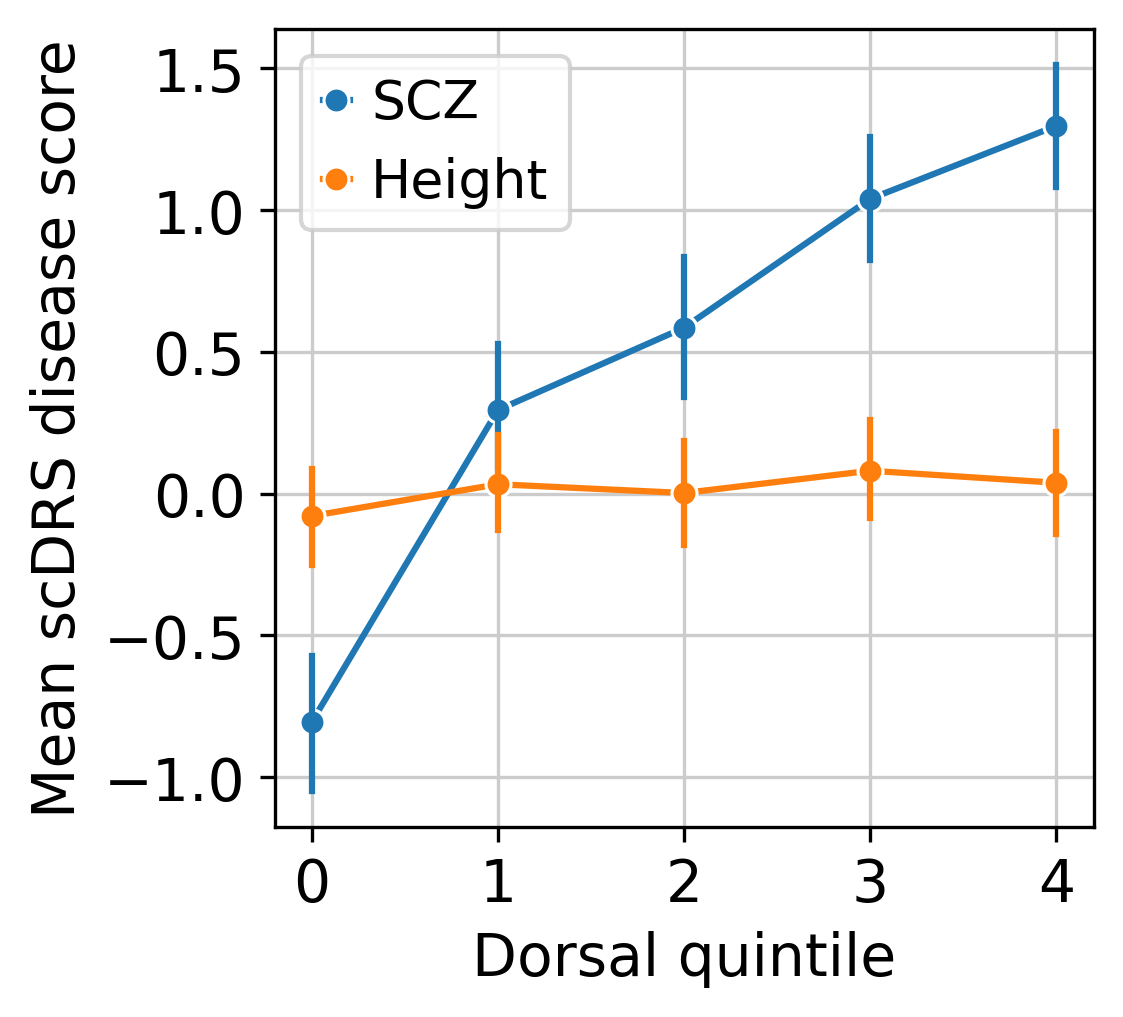

In [13]:
df_plot = adata_ca1.obs[["Dorsal", "SCZ", "Height"]].copy()
df_plot["Dorsal quintile"] = pd.qcut(df_plot["Dorsal"], 5, labels=np.arange(5))

fig, ax = plt.subplots(figsize=(3.5, 3.5))
for trait in ["SCZ", "Height"]:
    sns.lineplot(
        data=df_plot,
        x="Dorsal quintile",
        y=trait,
        label=trait,
        err_style="bars",
        marker="o",
        ax=ax,
    )
ax.set_xticks(np.arange(5))
ax.set_xlabel("Dorsal quintile")
ax.set_ylabel("Mean scDRS disease score")
fig.show()
plt.savefig("/public/work/Personal/renxiaozhen/pipline/scDRS/scDRS_ca1_dorsal_quintile.png", dpi=300)